# Landslide Runout Emulator — Uncertainty Demo

**Goal.** Show a fast workflow to predict landslide runout and propagate input uncertainty.


In [1]:
from runout_utils import prepare_case_chip
import matplotlib

matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
matplotlib.rcParams["figure.figsize"] = (6, 4)

Crop the Digital Elevation Model centered to the .kml point. Make sure the dem name is == to case.

✅ Saved chip: .\maoxian\dem.tif and .\maoxian\dem.npy


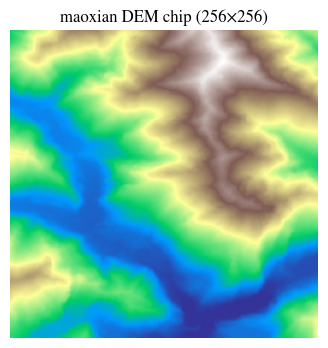

In [2]:
chip, transform, profile, paths = prepare_case_chip(
    case='maoxian',
    root=".",          
    size=256,
    save=True,
    plot=True,
)

# Generate predictions
Check if GPU is available

In [1]:
import torch
import numpy as np
from emulator import *

if torch.cuda.is_available():
    print("GPU is available.")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
else:
    print("GPU is not available, cannot produce forecast.")

GPU is available.
GPU name: NVIDIA RTX A4000


Run a single baseline simulation with custom parameters and visualize predicted runout mask and thickness over the DEM hillshade.

Warning! No geotransform defined. Choosing a standard one! (Top left cell's top let corner at <0,0>; cells are 1x1.)
Warning! No geotransform defined. Choosing a standard one! (Top left cell's top let corner at <0,0>; cells are 1x1.)
Warning! No geotransform defined. Choosing a standard one! (Top left cell's top let corner at <0,0>; cells are 1x1.)


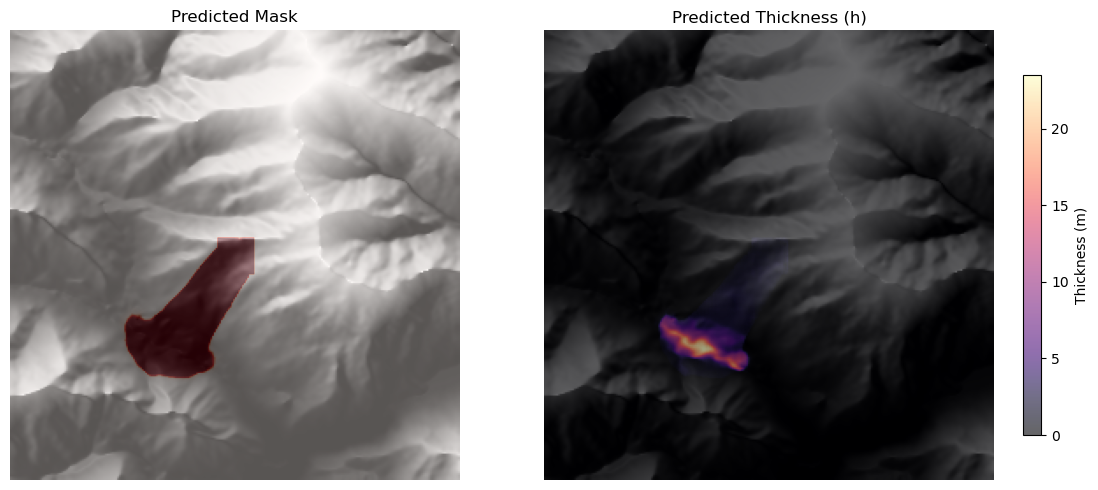

[{'cohesion': 25000.0,
  'rho': 1800.0,
  'volume': 9000000.0,
  'npz_path': 'maoxian/prepared\\dem_sim0001_c25000_r1800_v9M.npz',
  'final_npy_path': 'maoxian/output_nn\\dem_sim0001_c25000_r1800_v9M.npy'}]

In [3]:
baseline = dict(volume=9e6, cohesion=25000.0, rho=1800.0)

run_landslide_batch(
    landslide='maoxian',
    image_size=(256, 256),
    cell_size=30.0,
    cohesions=[baseline["cohesion"]],
    rhos=[baseline["rho"]],
    volumes=[baseline["volume"]],
    model_path="weights/final/best_model.pth",
    device="cuda",                 # "cpu" or "cuda" or "mps"
    plot=True,
    combination_mode="elementwise",   
    reuse_dist=True,                  
)

Generate Sobol samples across the parameter ranges (volume, cohesion, density) to explore uncertainty in a structured way.

In [4]:
case = "maoxian"
N = 1024  

samples = sobol_params(
    n=N,
    volume_range=(5e6, 1e7),
    cohesion_range=(5e3, 5e4),
    rho_range=(1600, 2400),
    seed=123,
    log_volume=True,
    
)
samples.head()

,volume,cohesion,rho
0,7.560891e+06,34536.816673,1970.197784
1,5.833662e+06,10246.142629,2239.140979
2,6.594380e+06,45474.637551,1652.740651
3,8.556972e+06,19689.628086,2131.450865
4,9.534197e+06,39750.993405,2385.937663


In [5]:
samples.to_csv('demo/maoxian_samples.csv')

Run the emulator once for each Sobol triplet (elementwise mode) to generate a full ensemble of runout predictions across the sampled parameter space.

In [ ]:
# Batch run
C = samples["cohesion"].to_numpy(float)
R = samples["rho"].to_numpy(float)
V = samples["volume"].to_numpy(float)

run_landslide_batch(
    landslide=case,
    image_size=(256, 256),
    cell_size=30.0,
    cohesions=C, rhos=R, volumes=V,
    model_path="weights/final/best_model.pth",
    device="cuda",                 # "cpu" or "cuda" or "mps"
    plot=False,
    combination_mode="elementwise",   # elementwise for Sobol triplets
    reuse_dist=True,                  # fast path if source footprint is fixed
)

Aggregate the ensemble of runouts into an exceedance probability map, save it as GeoTIFF, and plot it over the DEM hillshade.

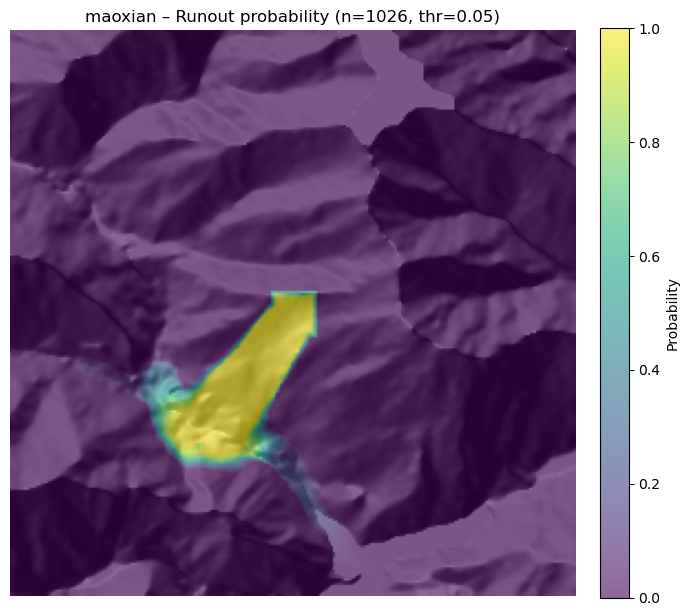

✅ Saved probability GeoTIFF: maoxian/output_nn\runout_probability.tif
🖼️ Saved overlay PNG:        maoxian/output_nn\runout_probability_overlay.png


In [1]:
from runout_utils import *

res = save_probability_and_plot(
    case='maoxian',
    threshold=0.05,
    match_shape="strict", 
    alpha=0.6,
    cmap="viridis",
)

Post-process the ensemble: compute exceedance probability, save as GeoTIFF and PNG overlay, and record metadata for reproducibility.

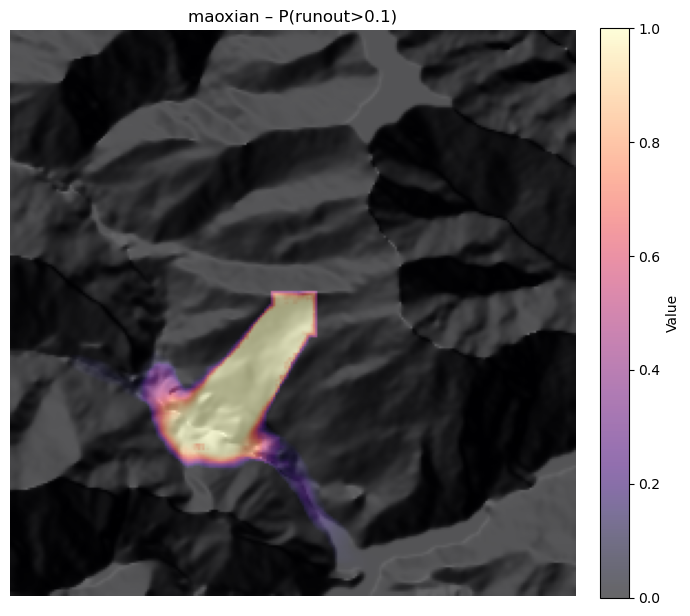

In [2]:
import os
from runout_utils import *

case = "maoxian"
out_dir = f"{case}/output_nn"
dem = f"{case}/dem.tif"
thr = 0.1

stack = load_runout_stack(out_dir, match_shape="strict")
prob = exceedance_probability(stack, threshold=thr)

prob_tif = os.path.join(out_dir, "prob_thr010.tif")
save_geotiff(prob, dem, prob_tif)
overlay_on_hillshade(prob, dem, title=f"{case} – P(runout>{thr})", out_png=os.path.join(out_dir, "prob_thr010.png"))

save_metadata_json(os.path.join(out_dir, "prob_thr010.meta.json"), {
    "case": case, "threshold": thr, "n_runs": int(stack.shape[0]), "shape": list(prob.shape)
})

Derive quantile maps (Q50, Q90) from the ensemble thickness predictions and overlay them on the DEM hillshade to visualize median vs. high-end scenarios.

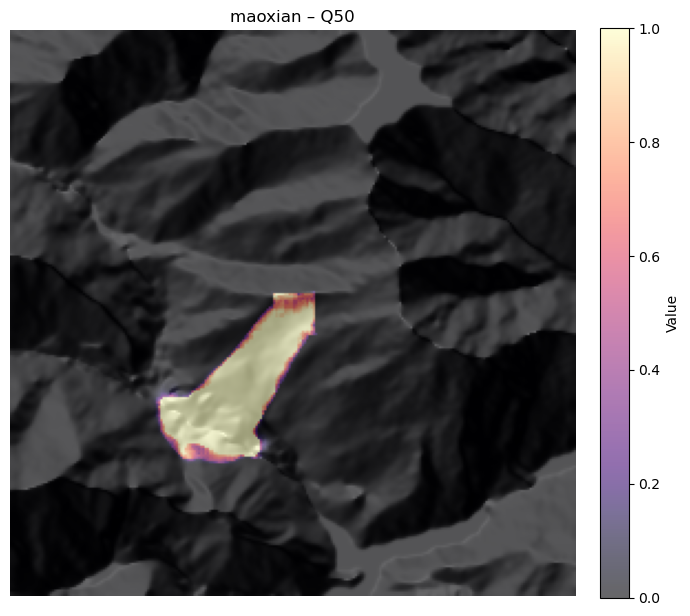

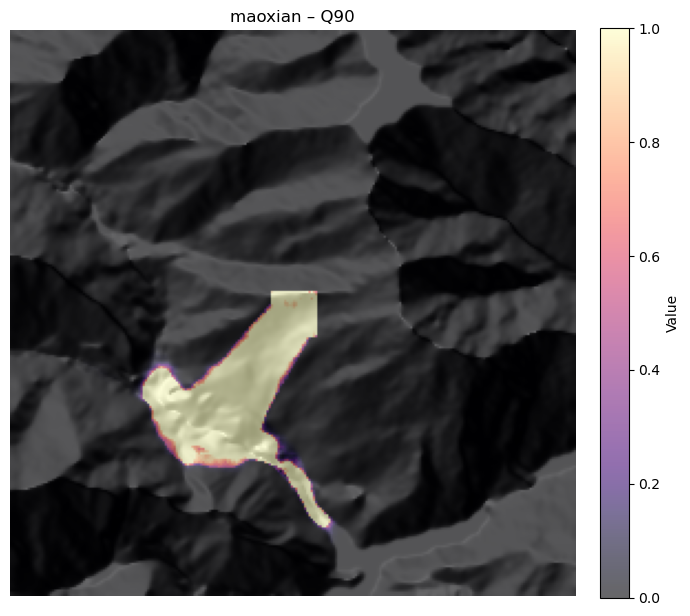

In [3]:
from runout_utils import percentile_maps

p50, p90 = percentile_maps(stack, [0.5, 0.9])
save_geotiff(p50, dem, os.path.join(out_dir, "q50.tif"))
save_geotiff(p90, dem, os.path.join(out_dir, "q90.tif"))
overlay_on_hillshade(p50, dem, title=f"{case} – Q50", out_png=os.path.join(out_dir, "q50.png"))
overlay_on_hillshade(p90, dem, title=f"{case} – Q90", out_png=os.path.join(out_dir, "q90.png"))